In [35]:
import mglearn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

X.shape: (26, 2)


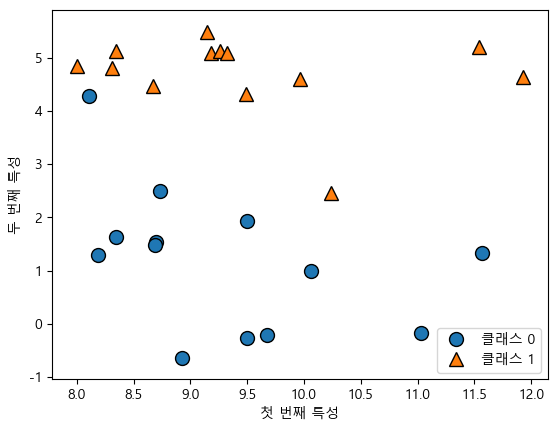

In [36]:
# 데이터셋 생성
X, y = mglearn.datasets.make_forge()

# 산점도 그리기
mglearn.discrete_scatter(
	X[:, 0],
	X[:, 1],
	y
)
plt.legend(["클래스 0", "클래스 1"], loc=4)
plt.xlabel("첫 번째 특성")
plt.ylabel("두 번째 특성")
print(f"X.shape: {X.shape}")

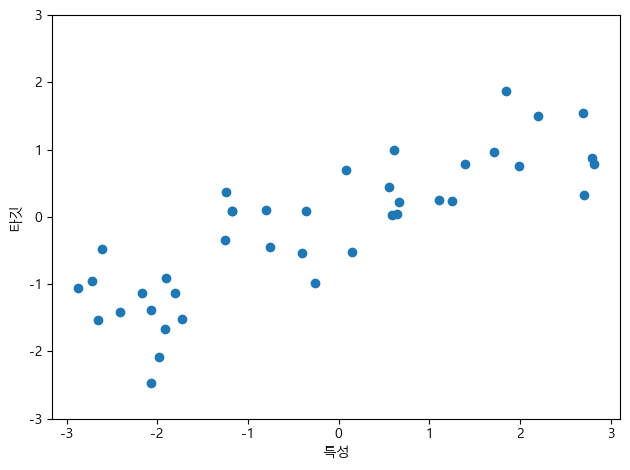

In [37]:
X, y = mglearn.datasets.make_wave(n_samples=40)
plt.plot(X, y, 'o')
plt.ylim(-3, 3)
plt.xlabel("특성")
plt.ylabel("타깃")
plt.tight_layout()
plt.show()

> 실제 데이터셋 1개: 유방암 종양의 임상 데이터 기록한 위스콘신 유방암 데이터셋  

양성(해롭지 않은 종양) 과 악성(암 종양)으로 레이블  
조직 데이터를 기반으로 종양이 악성인지를 예측할 수 있도록 학습  

In [38]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print(f"1. cancer.keys():\n   {cancer.keys()}")
print(f"2. 유방암 데이터의 형태: {cancer.data.shape}")
class_sample = {str(n): int(v) for n, v in zip(cancer.target_names, np.bincount(cancer.target))}
print(f"3. 클래스 별 샘플 갯수:\n  {class_sample}")
print(f"4. 특성 이름: \n  {cancer.feature_names}")

1. cancer.keys():
   dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
2. 유방암 데이터의 형태: (569, 30)
3. 클래스 별 샘플 갯수:
  {'malignant': 212, 'benign': 357}
4. 특성 이름: 
  ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


> 실제 데이터셋 2개: 보스턴 주택가격 데이터셋

범죄율, 찰스강 인접도, 고속도로 접근성 등의 정보를 이용,  
1970년대 보스턴 주변의 주택 평균 가격을 예측하는 것.  
506개의 데이터포인트, 13개의 특성이 존재하는 데이터셋.

In [39]:
data_url = "https://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(
	data_url,
	sep = "\s+",
	skiprows=22,
	header=None
)
data = np.hstack(
	[raw_df.values[::2, :], raw_df.values[1::2, :2]]
)
target = raw_df.values[1::2, 2]
print(f"데이터의 형태: {data.shape}")

데이터의 형태: (506, 13)


13개의 입력 특성 뿐만 아니라, 특성끼리 곱하여(상호작용) 의도적으로 피처를 확장.  
범죄율과 고속도로 접근성의 개별 특성은 물론,  
범죄율과 고속도로 접근성의 곱도 특성으로 생각한다는 뜻임.  

이러한 특성을 유도하는 것을 `피처 엔지니어링` 이라 일컫음.  
(유도된 데이터셋은 load_extended_boston 함수 사용)

13개 + 13개에서 2개씩 중복을 포함해 짝지은 91개의 특성을 더해 총 104개  

In [40]:
X, y = mglearn.datasets.load_extended_boston()
print(f"X.shape: {X.shape}")

X.shape: (506, 104)


> 2.3.2 KNN (K-최근접 이웃)

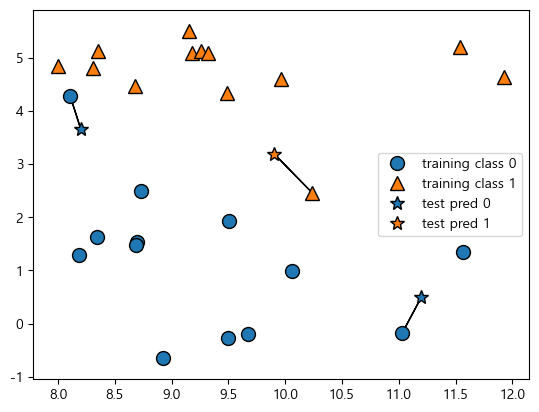

In [41]:
mglearn.plots.plot_knn_classification(n_neighbors=1)

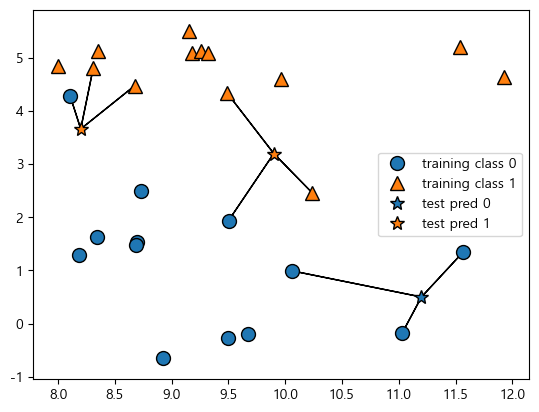

In [42]:
mglearn.plots.plot_knn_classification(n_neighbors=3)

Scikit-learn을 사용, KNN이 어떻게 적용하는지를 알아보자.

In [43]:
from sklearn.model_selection import train_test_split

# 데이터를 훈련 세트와 테스트 세트로 나눔
X, y = mglearn.datasets.make_forge()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
# clf = classifier(분류기)
clf = KNeighborsClassifier(n_neighbors=3)

In [44]:
clf.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [48]:
print(
	f"테스트 세트 예측: {clf.predict(X_test)}\n",
	f"테스트 세트 정확도: {format(clf.score(X_test, y_test))}"
)

테스트 세트 예측: [1 0 1 0 1 0 0]
 테스트 세트 정확도: 0.8571428571428571


>KNeighborsClassifier 분석

2차원 데이터셋이기 때문에, 가능한 모든 테스트 포인트의 예측을 좌표평면에 그릴 수 있음.  
